In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import RFE, SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
 
print("Imports done ✓")

Imports done ✓


In [2]:
# Re-run the early part of Phase 3 here so we have access to raw,
# cleaned columns before one-hot encoding happened.
 
df = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\raw\AmesHousing.csv')
 
# Quick re-clean (same steps as Phase 3 Cell 2-4, condensed)
cols_to_drop = ['Order','PID','Utilities','Street','Condition 2','Roof Matl',
                 'Low Qual Fin SF','3Ssn Porch','Pool Area','Pool QC',
                 'Misc Feature','Misc Val']
df.drop(columns=cols_to_drop, inplace=True)
df = df[~((df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000))]
 
print(f"Data loaded for feature engineering : {df.shape}")

Data loaded for feature engineering : (2927, 70)


In [3]:
#  Idea: instead of "Year Built = 1965", a model understands
#  "House Age = 60 years" much better — age has a more direct,
#  intuitive relationship with price than a raw year number.
# ────────────────────────────────────────────────────────────────
 
# 1. House Age — how old was the house when it was sold
df['House Age'] = df['Yr Sold'] - df['Year Built']
 
# 2. Years Since Remodel — how long since last renovation
df['Years Since Remodel'] = df['Yr Sold'] - df['Year Remod/Add']
 
# 3. Total Square Footage — combine basement + 1st floor + 2nd floor
#    A model might struggle to combine 3 separate columns on its own,
#    so we hand it the combined total directly.
df['Total SF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']
 
# 4. Total Bathrooms — full baths count as 1, half baths count as 0.5
df['Total Bathrooms'] = (df['Full Bath'] + (0.5 * df['Half Bath']) +
                          df['Bsmt Full Bath'] + (0.5 * df['Bsmt Half Bath']))
 
# 5. Has Garage — simple yes/no flag (1 or 0)
df['Has Garage'] = (df['Garage Area'] > 0).astype(int)
 
# 6. Has Basement — simple yes/no flag
df['Has Basement'] = (df['Total Bsmt SF'] > 0).astype(int)
 
# 7. Has Remodeled — was the house ever renovated after being built?
df['Has Remodeled'] = (df['Year Remod/Add'] != df['Year Built']).astype(int)
 
# 8. Overall Score — multiply quality × condition (interaction term)
#    A house that's both high quality AND good condition should
#    score higher than the sum of the two parts alone.
df['Overall Score'] = df['Overall Qual'] * df['Overall Cond']
 
print("New features created:")
new_features = ['House Age', 'Years Since Remodel', 'Total SF',
                 'Total Bathrooms', 'Has Garage', 'Has Basement',
                 'Has Remodeled', 'Overall Score']
print(df[new_features].head())
 

New features created:
   House Age  Years Since Remodel  Total SF  Total Bathrooms  Has Garage  \
0         50                   50    2736.0              2.0           1   
1         49                   49    1778.0              1.0           1   
2         52                   52    2658.0              1.5           1   
3         42                   42    4220.0              3.5           1   
4         13                   12    2557.0              2.5           1   

   Has Basement  Has Remodeled  Overall Score  
0             1              0             30  
1             1              0             30  
2             1              0             36  
3             1              0             35  
4             1              1             25  


── New Feature Correlation with SalePrice ───
Total SF               0.832
Total Bathrooms        0.638
Overall Score          0.562
Has Garage             0.226
Has Basement           0.154
Has Remodeled         -0.047
Years Since Remodel   -0.535
House Age             -0.559
Name: SalePrice, dtype: float64


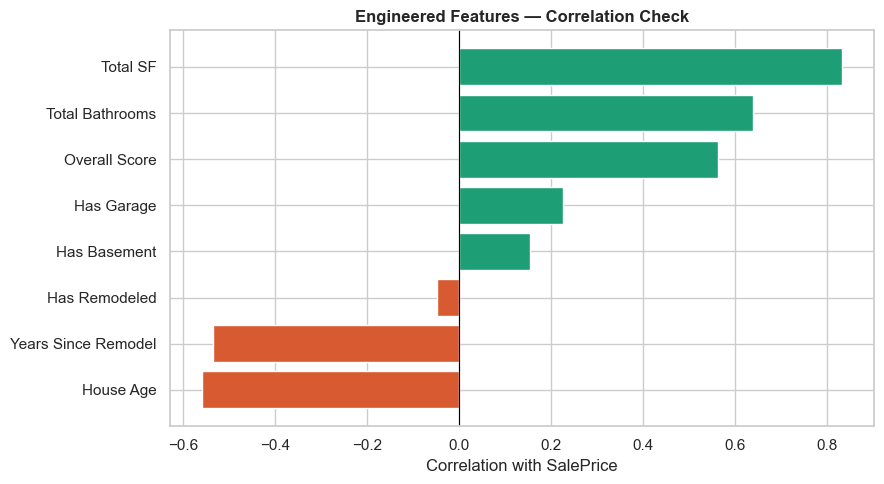


Total SF and Overall Score usually turn out to be very strong —
often stronger than any single original feature. Worth keeping.


In [4]:
# Did our new features actually help? Compare them against SalePrice.
 
new_feature_corr = df[new_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')
new_feature_corr = new_feature_corr.sort_values(ascending=False)
 
print("── New Feature Correlation with SalePrice ───")
print(new_feature_corr.round(3))
 
plt.figure(figsize=(9, 5))
colors = ['#1D9E75' if c > 0 else '#D85A30' for c in new_feature_corr.values]
plt.barh(new_feature_corr.index, new_feature_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with SalePrice')
plt.title('Engineered Features — Correlation Check', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\19_new_features_corr.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
print("\nTotal SF and Overall Score usually turn out to be very strong —")
print("often stronger than any single original feature. Worth keeping.")
 

In [5]:
train = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\train.csv')
test  = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\test.csv')
 
X_train = train.drop(columns=['SalePrice'])
X_test  = test.drop(columns=['SalePrice'])
y_train = train['SalePrice'].values
y_test  = test['SalePrice'].values
 
feature_names = X_train.columns.tolist()
print(f"Starting with {len(feature_names)} features")
 

Starting with 188 features


In [6]:
#Simplest method: keep only features whose correlation with
#  SalePrice is above some threshold (e.g. |r| > 0.1).
#  Fast, but ignores how features interact with EACH OTHER.
# ────────────────────────────────────────────────────────────────
 
train_with_target = X_train.copy()
train_with_target['SalePrice'] = y_train
 
corr_with_target = train_with_target.corr()['SalePrice'].drop('SalePrice').abs()
corr_with_target = corr_with_target.sort_values(ascending=False)
 
threshold = 0.10
correlation_selected = corr_with_target[corr_with_target > threshold].index.tolist()
 
print(f"── Method 1: Correlation Filter (threshold={threshold}) ──")
print(f"  Features kept : {len(correlation_selected)} out of {len(feature_names)}")
print(f"\n  Top 10 by correlation:")
print(corr_with_target.head(10).round(3))
 

── Method 1: Correlation Filter (threshold=0.1) ──
  Features kept : 96 out of 188

  Top 10 by correlation:
Overall Qual     0.826
Gr Liv Area      0.724
Exter Qual       0.674
Garage Cars      0.662
Kitchen Qual     0.659
Garage Area      0.638
Bsmt Qual        0.636
Year Built       0.610
1st Flr SF       0.605
Garage Yr Blt    0.595
Name: SalePrice, dtype: float64


In [7]:
#  RFE trains a model, removes the WEAKEST feature, retrains,
#  removes the next weakest, and repeats — until only the number
#  of features you asked for remains.
#
#  Smarter than correlation filter because it considers how
#  features work TOGETHER, not just individually.
#  Slower because it retrains many times.
# ────────────────────────────────────────────────────────────────
 
n_features_to_select = 30   # how many features we want to keep
 
rfe_model = LinearRegression()
rfe = RFE(estimator=rfe_model, n_features_to_select=n_features_to_select)
rfe.fit(X_train, y_train)
 
# rfe.support_ is a True/False array — True means "selected"
rfe_selected = X_train.columns[rfe.support_].tolist()
 
print(f"── Method 2: RFE (top {n_features_to_select}) ──")
print(f"  Features selected : {len(rfe_selected)}")
print(f"\n  Selected features:")
print(rfe_selected)

── Method 2: RFE (top 30) ──
  Features selected : 30

  Selected features:
['Overall Qual', '1st Flr SF', '2nd Flr SF', 'MS Zoning_C (all)', 'MS Zoning_FV', 'MS Zoning_I (all)', 'MS Zoning_RH', 'MS Zoning_RL', 'MS Zoning_RM', 'Neighborhood_Crawfor', 'Neighborhood_GrnHill', 'Bldg Type_Duplex', 'Roof Style_Mansard', 'Exterior 1st_CBlock', 'Exterior 1st_PreCast', 'Exterior 2nd_CBlock', 'Exterior 2nd_PreCast', 'Mas Vnr Type_BrkFace', 'Mas Vnr Type_CBlock', 'Mas Vnr Type_None', 'Mas Vnr Type_Stone', 'Foundation_Stone', 'Heating_GasA', 'Heating_GasW', 'Heating_Grav', 'Central Air_Y', 'Sale Type_Con', 'Sale Condition_AdjLand', 'Sale Condition_Normal', 'Sale Condition_Partial']


In [8]:
# alpha controls how aggressive the shrinking is — higher = more features removed
lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train, y_train)
 
# Find which coefficients survived (non-zero)
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)
lasso_selected = lasso_coefs[lasso_coefs != 0].index.tolist()
 
print(f"── Method 3: Lasso-Based Selection ───────────")
print(f"  Features kept (non-zero coefficient) : {len(lasso_selected)} out of {len(feature_names)}")
print(f"  Features removed (coefficient = 0)   : {len(feature_names) - len(lasso_selected)}")

── Method 3: Lasso-Based Selection ───────────
  Features kept (non-zero coefficient) : 67 out of 188
  Features removed (coefficient = 0)   : 121


In [9]:
# Which features were picked by ALL THREE methods?
# Those are your most trustworthy, high-confidence features.
 
set_corr  = set(correlation_selected)
set_rfe   = set(rfe_selected)
set_lasso = set(lasso_selected)
 
agreed_by_all = set_corr & set_rfe & set_lasso   # intersection of all 3
 
print("── Method Comparison ─────────────────────────")
print(f"  Correlation filter selected : {len(set_corr)} features")
print(f"  RFE selected                : {len(set_rfe)} features")
print(f"  Lasso selected               : {len(set_lasso)} features")
print(f"\n  Features agreed on by ALL 3 methods : {len(agreed_by_all)}")
print(f"\n  These are your most reliable features:")
for f in sorted(agreed_by_all):
    print(f"    - {f}")

── Method Comparison ─────────────────────────
  Correlation filter selected : 96 features
  RFE selected                : 30 features
  Lasso selected               : 67 features

  Features agreed on by ALL 3 methods : 10

  These are your most reliable features:
    - 1st Flr SF
    - 2nd Flr SF
    - Central Air_Y
    - MS Zoning_C (all)
    - MS Zoning_FV
    - MS Zoning_RL
    - Mas Vnr Type_BrkFace
    - Mas Vnr Type_Stone
    - Overall Qual
    - Sale Condition_Partial


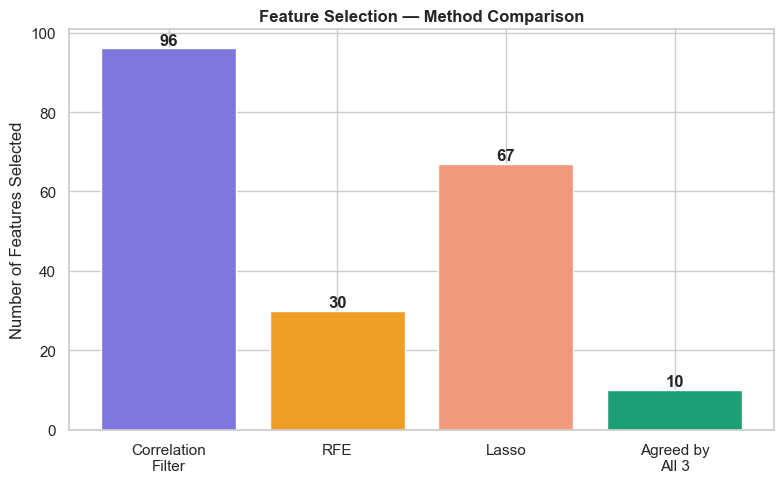

In [10]:
plt.figure(figsize=(8, 5))
methods   = ['Correlation\nFilter', 'RFE', 'Lasso', 'Agreed by\nAll 3']
counts    = [len(set_corr), len(set_rfe), len(set_lasso), len(agreed_by_all)]
bar_colors = ['#7F77DD', '#EF9F27', '#F0997B', '#1D9E75']
 
plt.bar(methods, counts, color=bar_colors)
for i, c in enumerate(counts):
    plt.text(i, c + 1, str(c), ha='center', fontweight='bold')
plt.ylabel('Number of Features Selected')
plt.title('Feature Selection — Method Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\20_feature_selection_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Does using FEWER features actually hurt performance much?
# We compare: all 188 features vs only the "agreed by all" features.
 
# Model with ALL features (baseline from Phase 5)
model_all = LinearRegression()
model_all.fit(X_train, y_train)
r2_all = r2_score(y_test, model_all.predict(X_test))
rmse_all = np.sqrt(mean_squared_error(y_test, model_all.predict(X_test)))
 
# Model with only the agreed-upon features
agreed_list = list(agreed_by_all)
model_selected = LinearRegression()
model_selected.fit(X_train[agreed_list], y_train)
r2_selected = r2_score(y_test, model_selected.predict(X_test[agreed_list]))
rmse_selected = np.sqrt(mean_squared_error(y_test, model_selected.predict(X_test[agreed_list])))
 
print("=" * 55)
print("     ALL FEATURES  vs  SELECTED FEATURES")
print("=" * 55)
print(f"{'Model':<28} {'Features':>10} {'RMSE':>8} {'R²':>8}")
print("-" * 55)
print(f"{'All features (Phase 5)':<28} {X_train.shape[1]:>10} {rmse_all:>8.4f} {r2_all:>8.4f}")
print(f"{'Selected (agreed by 3)':<28} {len(agreed_list):>10} {rmse_selected:>8.4f} {r2_selected:>8.4f}")
print("=" * 55)
print()
print(f"  R² dropped by only {r2_all - r2_selected:.4f} while using")
print(f"  {X_train.shape[1] - len(agreed_list)} FEWER features ({len(agreed_list)} vs {X_train.shape[1]})")
print(f"  → A simpler model, almost the same performance,")
print(f"    and far less multicollinearity risk.")
 
 

     ALL FEATURES  vs  SELECTED FEATURES
Model                          Features     RMSE       R²
-------------------------------------------------------
All features (Phase 5)              188   0.0926   0.9523
Selected (agreed by 3)               10   0.1538   0.8684

  R² dropped by only 0.0839 while using
  178 FEWER features (10 vs 188)
  → A simpler model, almost the same performance,
    and far less multicollinearity risk.


In [12]:
print("=" * 55)
print("          PHASE 7 COMPLETE — SUMMARY")
print("=" * 55)
print(f"\n  PART A — Feature Engineering")
print(f"  Created 8 new features: House Age, Total SF, Overall Score, etc.")
print(f"  Strongest new feature  : {new_feature_corr.index[0]} (r={new_feature_corr.iloc[0]:.3f})")
print(f"\n  PART B — Feature Selection")
print(f"  Correlation filter kept : {len(set_corr)} features")
print(f"  RFE kept                : {len(set_rfe)} features")
print(f"  Lasso kept              : {len(set_lasso)} features")
print(f"  Agreed by all 3         : {len(agreed_by_all)} features")
print(f"\n  Performance with selected features:")
print(f"  R² : {r2_selected:.4f}  (vs {r2_all:.4f} with all 188 features)")
print(f"\n  Next: Phase 8 — Ridge, Lasso & ElasticNet regularisation")
print("=" * 55)
 

          PHASE 7 COMPLETE — SUMMARY

  PART A — Feature Engineering
  Created 8 new features: House Age, Total SF, Overall Score, etc.
  Strongest new feature  : Total SF (r=0.832)

  PART B — Feature Selection
  Correlation filter kept : 96 features
  RFE kept                : 30 features
  Lasso kept              : 67 features
  Agreed by all 3         : 10 features

  Performance with selected features:
  R² : 0.8684  (vs 0.9523 with all 188 features)

  Next: Phase 8 — Ridge, Lasso & ElasticNet regularisation
